# 🏥 Machine Learning aplicado al Triage de COVID-19
### Predicción de Hospitalización de Pacientes con Datos Clínicos de México

---

| Dato | Descripción |
|---|---|
| **Dataset** | Datos Abiertos COVID-19 — Gobierno de México |
| **Objetivo** | Predecir si un paciente debe ser **hospitalizado** o puede ir a **casa** |
| **Momento** | El modelo toma la decisión en el **Minuto 1 del Triage** |
| **Técnica** | Clasificación Binaria con Machine Learning |

---

## 🎯 El Problema que Resolvemos

Imagina que eres un médico en urgencias durante la pandemia de COVID-19.  
Llega un paciente con síntomas. Tienes **muy poco tiempo** para decidir:

> *¿Este paciente necesita una cama de hospital, o puede recuperarse en casa?*

Tomar la decisión equivocada tiene consecuencias graves:
- **Error Tipo 1**: Enviar a casa a alguien que necesita hospitalización → **Podría morir**
- **Error Tipo 2**: Hospitalizar a alguien que no lo necesita → **Ocupa una cama que otro paciente necesita**

Este proyecto entrena a una computadora para **ayudar al médico a tomar esa decisión**, usando información clínica disponible en el momento de llegada al hospital.

---

## 🗺️ Mapa del Notebook (¿Qué vamos a aprender?)

```
SECCIÓN 0  →  Portada y Contexto
SECCIÓN 1  →  ¿Qué es Machine Learning? (con analogías)
SECCIÓN 2  →  Las Herramientas (Librerías de Python)
SECCIÓN 3  →  Los Datos (Dataset de 263,000 pacientes)
SECCIÓN 4  →  Auditoría Anti-Trampa (Data Leakage)
SECCIÓN 5  →  Limpieza de Datos
SECCIÓN 6  →  Análisis Visual (¿Quién tiene más riesgo?)
SECCIÓN 7  →  División Entrenamiento / Prueba
SECCIÓN 8  →  El Pipeline de ML (cadena de montaje)
SECCIÓN 9  →  Modelo Base de Comparación (Benchmark)
SECCIÓN 10 →  Comparación de 3 Algoritmos de ML
SECCIÓN 11 →  Optimización del Mejor Modelo
SECCIÓN 12 →  Resultados Finales e Interpretación
SECCIÓN 13 →  Conclusiones
```


---
# 🤖 Sección 1 — ¿Qué es Machine Learning?

## La Analogía del Médico Experimentado

Piensa en cómo aprende un médico con 30 años de experiencia:

1. **Observa miles de pacientes** a lo largo de su carrera
2. **Detecta patrones**: "Cuando un paciente tiene más de 65 años, diabetes e hipertensión, tiende a complicarse"
3. **Aplica ese conocimiento** cuando llega un nuevo paciente

Pues bien, **Machine Learning hace exactamente lo mismo**, pero con una computadora:

```
MÉDICO HUMANO                    MODELO DE ML
─────────────────────            ─────────────────────
Lee historial de pacientes   →   Lee filas de un dataset
Memoriza patrones clínicos   →   Ajusta parámetros matemáticos
Da un diagnóstico nuevo      →   Hace una predicción nueva
Mejora con la experiencia    →   Mejora con más datos
```

## Los 3 Elementos Clave de ML

| Elemento | En Medicina | En este Proyecto |
|---|---|---|
| **Datos de Entrenamiento** | Historiales de pacientes pasados | 263,007 registros de COVID-19 |
| **Algoritmo** | El "cerebro" del médico | Random Forest, Regresión Logística... |
| **Predicción** | Diagnóstico | Hospitalizado (1) o Ambulatorio (0) |

## ¿Qué tipo de ML usamos aquí?

Usamos **Clasificación Supervisada**:
- **Supervisada** = Le mostramos al modelo ejemplos con la respuesta correcta ("este paciente fue hospitalizado", "este otro no")
- **Clasificación** = La respuesta es una categoría, no un número continuo (Hospitalizado vs Ambulatorio)

> 🚨 **¡Importante!** El modelo aprende de casos del *pasado* para predecir casos del *futuro*. Por eso es fundamental que no le "filtremos" información del futuro durante el entrenamiento (esto se llama **Data Leakage** y lo veremos en la Sección 4).


---
# 🛠️ Sección 2 — Las Herramientas (Librerías de Python)

Antes de empezar a cocinar, necesitamos los utensilios de cocina.  
En Python, los "utensilios" se llaman **librerías** — son colecciones de funciones ya escritas por otros.

| Librería | Para qué sirve | Analogía |
|---|---|---|
| `pandas` | Manejar tablas de datos | Excel pero programable |
| `numpy` | Cálculos matemáticos | Calculadora científica avanzada |
| `matplotlib` | Crear gráficos | Microsoft Paint pero preciso |
| `seaborn` | Gráficos bonitos | matplotlib con mejor diseño |
| `sklearn` | Machine Learning | La caja de herramientas de ML |

La siguiente celda **importa** todas las herramientas que vamos a usar en el proyecto.


In [2]:
# ═══════════════════════════════════════════════════════════
# IMPORTACIÓN DE LIBRERÍAS
# Ejecuta esta celda primero — carga todas las herramientas
# ═══════════════════════════════════════════════════════════

# --- Manipulación y análisis de datos ---
import pandas as pd          # Tablas de datos (DataFrames)
import numpy as np           # Operaciones matemáticas

# --- Visualización de datos ---
import matplotlib.pyplot as plt   # Gráficos base
import seaborn as sns              # Gráficos estadísticos más elegantes

# --- Machine Learning: División de datos ---
from sklearn.model_selection import train_test_split      # Dividir en train/test
from sklearn.model_selection import StratifiedKFold       # Validación cruzada estratificada
from sklearn.model_selection import cross_validate        # Ejecutar validación cruzada
from sklearn.model_selection import RandomizedSearchCV    # Búsqueda de hiperparámetros

# --- Machine Learning: Preprocesamiento ---
from sklearn.compose import ColumnTransformer   # Aplicar transformaciones por columna
from sklearn.pipeline import Pipeline           # Encadenar pasos de ML
from sklearn.impute import SimpleImputer        # Rellenar valores faltantes (NaN)
from sklearn.preprocessing import StandardScaler # Normalizar datos

# --- Machine Learning: Modelos ---
from sklearn.dummy import DummyClassifier           # Modelo base (referencia)
from sklearn.linear_model import LogisticRegression # Regresión Logística
from sklearn.ensemble import RandomForestClassifier # Random Forest (Bosque Aleatorio)
from sklearn.neural_network import MLPClassifier    # Red Neuronal (Multi-Layer Perceptron)

# --- Machine Learning: Métricas de evaluación ---
from sklearn.metrics import (
    accuracy_score,          # Precisión global
    precision_score,         # Precisión (de los que predije positivo, ¿cuántos lo eran?)
    recall_score,            # Sensibilidad (de los positivos reales, ¿cuántos detecté?)
    f1_score,                # Balance entre precision y recall
    roc_auc_score,           # Área bajo la curva ROC
    average_precision_score, # Área bajo la curva Precision-Recall (PR-AUC)
    confusion_matrix         # Matriz de confusión
)
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

# --- Configuración de visualización ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ ¡Todas las librerías cargadas correctamente!")
print("   Versión de pandas:", pd.__version__)
print("   Versión de scikit-learn:", __import__('sklearn').__version__)


✅ ¡Todas las librerías cargadas correctamente!
   Versión de pandas: 2.3.3
   Versión de scikit-learn: 1.7.2


---
# 📊 Sección 3 — Los Datos: Dataset de COVID-19

## ¿Qué es un Dataset?

Un **dataset** es simplemente una tabla de datos — como una hoja de Excel gigante.

En nuestro caso:
- Cada **fila** = Un **paciente** que llegó a urgencias con COVID-19
- Cada **columna** = Una **característica** del paciente (edad, si tiene diabetes, si fue hospitalizado, etc.)

## ¿De dónde vienen estos datos?

Los datos son los **Datos Abiertos de COVID-19** publicados por la Secretaría de Salud de México.  
Contienen registros anónimos de pacientes atendidos en hospitales mexicanos durante la pandemia.

## ¿Qué vamos a explorar?

Antes de entrenar cualquier modelo, un científico de datos siempre **explora los datos primero**:
- ¿Cuántos pacientes hay?
- ¿Cuántas columnas (características) tenemos?
- ¿Hay datos faltantes?
- ¿Están los datos bien formateados?

> 🔍 **Analogía**: Antes de cocinar, un chef revisa los ingredientes: ¿están frescos? ¿hay suficiente cantidad? ¿están bien preparados?


In [3]:
# ═══════════════════════════════════════════════════════════
# CARGA DEL DATASET
# ═══════════════════════════════════════════════════════════

# Cargamos el archivo CSV en un DataFrame de pandas
# Un DataFrame es como una hoja de Excel en Python
df = pd.read_csv('mexico_covid19.csv')

print("=" * 60)
print("RESUMEN INICIAL DEL DATASET")
print("=" * 60)
print(f"📏 Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"   → {df.shape[0]:,} pacientes")
print(f"   → {df.shape[1]} características por paciente")
print()
print("📋 Nombres de todas las columnas:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")


RESUMEN INICIAL DEL DATASET
📏 Dimensiones: 263,007 filas x 41 columnas
   → 263,007 pacientes
   → 41 características por paciente

📋 Nombres de todas las columnas:
    1. id
    2. FECHA_ARCHIVO
    3. ID_REGISTRO
    4. ENTIDAD_UM
    5. ENTIDAD_RES
    6. RESULTADO
    7. DELAY
    8. ENTIDAD_REGISTRO
    9. ENTIDAD
   10. ABR_ENT
   11. FECHA_ACTUALIZACION
   12. ORIGEN
   13. SECTOR
   14. SEXO
   15. ENTIDAD_NAC
   16. MUNICIPIO_RES
   17. TIPO_PACIENTE
   18. FECHA_INGRESO
   19. FECHA_SINTOMAS
   20. FECHA_DEF
   21. INTUBADO
   22. NEUMONIA
   23. EDAD
   24. NACIONALIDAD
   25. EMBARAZO
   26. HABLA_LENGUA_INDIG
   27. DIABETES
   28. EPOC
   29. ASMA
   30. INMUSUPR
   31. HIPERTENSION
   32. OTRA_COM
   33. CARDIOVASCULAR
   34. OBESIDAD
   35. RENAL_CRONICA
   36. TABAQUISMO
   37. OTRO_CASO
   38. MIGRANTE
   39. PAIS_NACIONALIDAD
   40. PAIS_ORIGEN
   41. UCI


In [4]:
# ═══════════════════════════════════════════════════════════
# EXPLORACIÓN: PRIMERAS FILAS
# ═══════════════════════════════════════════════════════════

print("📄 Primeros 5 registros (pacientes) del dataset:")
print("   (cada fila es un paciente, cada columna una característica)")
print()
df.head()


📄 Primeros 5 registros (pacientes) del dataset:
   (cada fila es un paciente, cada columna una característica)



,id,FECHA_ARCHIVO,ID_REGISTRO,ENTIDAD_UM,ENTIDAD_RES,RESULTADO,DELAY,ENTIDAD_REGISTRO,ENTIDAD,ABR_ENT,...,OTRA_COM,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,9269,2020-04-12,00011f,25,25,2,0,25,Sinaloa,SL,...,2,2,1,2,2,2,99,MÃ©xico,97,97
1,33333,2020-04-12,00014e,14,14,2,0,14,Jalisco,JC,...,2,2,1,2,1,99,99,MÃ©xico,97,2
2,35483,2020-04-12,000153,8,8,1,0,8,Chihuahua,CH,...,2,2,2,2,2,99,99,MÃ©xico,97,2
3,7062,2020-04-12,0001b6,9,15,1,0,9,Ciudad de Mexico,DF,...,2,2,1,2,2,99,99,MÃ©xico,97,97
4,23745,2020-04-12,0001c1,9,9,2,0,9,Ciudad de Mexico,DF,...,2,2,2,2,2,99,99,MÃ©xico,97,97


In [5]:
# ═══════════════════════════════════════════════════════════
# EXPLORACIÓN: TIPOS DE DATOS Y VALORES NULOS
# ═══════════════════════════════════════════════════════════

print("📊 Información general del dataset:")
print("   - dtype: tipo de dato de cada columna (int64 = número entero, object = texto)")
print("   - non-null: cuántas filas tienen datos en esa columna")
print()
df.info()


📊 Información general del dataset:
   - dtype: tipo de dato de cada columna (int64 = número entero, object = texto)
   - non-null: cuántas filas tienen datos en esa columna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263007 entries, 0 to 263006
Data columns (total 41 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   263007 non-null  int64  
 1   FECHA_ARCHIVO        263007 non-null  object 
 2   ID_REGISTRO          263007 non-null  object 
 3   ENTIDAD_UM           263007 non-null  int64  
 4   ENTIDAD_RES          263007 non-null  int64  
 5   RESULTADO            263007 non-null  int64  
 6   DELAY                263007 non-null  int64  
 7   ENTIDAD_REGISTRO     263007 non-null  int64  
 8   ENTIDAD              263007 non-null  object 
 9   ABR_ENT              263007 non-null  object 
 10  FECHA_ACTUALIZACION  263007 non-null  object 
 11  ORIGEN               263007 non-null  int64  
 

In [6]:
# ═══════════════════════════════════════════════════════════
# EXPLORACIÓN: ESTADÍSTICAS DESCRIPTIVAS
# ═══════════════════════════════════════════════════════════

print("📈 Estadísticas descriptivas (solo columnas numéricas):")
print("   - count: número de valores no nulos")
print("   - mean: promedio")
print("   - std: desviación estándar (qué tan dispersos están los datos)")
print("   - min/max: mínimo y máximo")
print("   - 25%/50%/75%: percentiles")
print()
df.describe().round(2)


📈 Estadísticas descriptivas (solo columnas numéricas):
   - count: número de valores no nulos
   - mean: promedio
   - std: desviación estándar (qué tan dispersos están los datos)
   - min/max: mínimo y máximo
   - 25%/50%/75%: percentiles



,id,ENTIDAD_UM,ENTIDAD_RES,RESULTADO,DELAY,ENTIDAD_REGISTRO,ORIGEN,SECTOR,SEXO,ENTIDAD_NAC,...,INMUSUPR,HIPERTENSION,OTRA_COM,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,MIGRANTE,UCI
count,263007.00,263007.00,263007.00,263007.00,263007.0,263007.00,263007.00,263007.00,263007.00,263007.00,...,263007.00,263007.00,263007.00,263007.00,263007.00,263007.00,263007.00,263007.00,263007.00,263007.00
mean,2946176.33,14.84,15.13,1.61,0.0,15.09,1.64,9.60,1.51,19.69,...,2.36,2.17,2.45,2.32,2.18,2.32,2.27,32.28,98.59,74.54
std,2212368.40,8.00,7.90,0.49,0.0,7.92,0.48,7.27,0.50,19.38,...,6.02,5.75,6.85,5.80,5.82,5.72,5.87,45.35,6.28,40.38
min,1.00,1.00,1.00,1.00,0.0,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,868963.50,9.00,9.00,1.00,0.0,9.00,1.00,4.00,1.00,9.00,...,2.00,2.00,2.00,2.00,2.00,2.00,2.00,1.00,99.00,97.00
50%,2733242.00,14.00,15.00,2.00,0.0,15.00,2.00,12.00,2.00,15.00,...,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,99.00,97.00
75%,4789667.50,21.00,21.00,2.00,0.0,21.00,2.00,12.00,2.00,24.00,...,2.00,2.00,2.00,2.00,2.00,2.00,2.00,99.00,99.00,97.00
max,7277125.00,32.00,32.00,2.00,0.0,32.00,2.00,99.00,2.00,99.00,...,98.00,98.00,98.00,98.00,98.00,98.00,98.00,99.00,99.00,99.00


In [6]:
# ═══════════════════════════════════════════════════════════
# EXPLORACIÓN: VARIABLE OBJETIVO — TIPO_PACIENTE
# ═══════════════════════════════════════════════════════════

print("🎯 Distribución de la Variable Objetivo (TIPO_PACIENTE):")
print("   1 = Paciente Ambulatorio (va a casa)")
print("   2 = Paciente Hospitalizado (queda ingresado)")
print()

conteo = df['TIPO_PACIENTE'].value_counts()
for val, count in conteo.items():
    etiqueta = "Ambulatorio" if val == 1 else "Hospitalizado"
    porcentaje = count / len(df) * 100
    barra = "█" * int(porcentaje / 2)
    print(f"   {val} ({etiqueta:12}): {count:8,d} pacientes ({porcentaje:.1f}%) {barra}")

print()
print("⚠️  IMPORTANTE: El dataset está DESBALANCEADO.")
print("   Hay ~3x más pacientes ambulatorios que hospitalizados.")
print("   Esto afecta cómo elegimos nuestras métricas de evaluación.")


🎯 Distribución de la Variable Objetivo (TIPO_PACIENTE):
   1 = Paciente Ambulatorio (va a casa)
   2 = Paciente Hospitalizado (queda ingresado)

   1 (Ambulatorio ):  200,838 pacientes (76.4%) ██████████████████████████████████████
   2 (Hospitalizado):   62,169 pacientes (23.6%) ███████████

⚠️  IMPORTANTE: El dataset está DESBALANCEADO.
   Hay ~3x más pacientes ambulatorios que hospitalizados.
   Esto afecta cómo elegimos nuestras métricas de evaluación.


---
# 🚫 Sección 4 — Auditoría Anti-Trampa: El Data Leakage

## ¿Qué es el Data Leakage? (Fuga de Datos)

Esta es **la trampa más peligrosa** en Machine Learning.  
Ocurre cuando el modelo aprende información que **no estaría disponible en la realidad** al momento de hacer la predicción.

## La Analogía del Examen con las Respuestas

Imagina que estás preparando a un estudiante para un examen:

```
❌ MAL (Data Leakage):
   Estudiante entrena con los exámenes de años anteriores...
   ¡CON LAS RESPUESTAS YA ESCRITAS EN LOS EJERCICIOS!
   → El estudiante parece "brillante" en el entrenamiento
   → Pero fracasa en el examen real porque no sabe NADA
   
✅ BIEN (Sin Leakage):
   Estudiante entrena con los ejercicios pero SIN respuestas
   → Aprende a razonar
   → Rinde bien en el examen real
```

## En Nuestro Caso: El Triage del Minuto 1

Nuestro modelo se usa en el **Minuto 1**: el médico ve al paciente por primera vez.  
En ese momento, el médico **NO SABE**:
- Si el paciente acabará en la UCI (UCI/INTUBADO)
- Si el paciente morirá (FECHA_DEF)
- El resultado del test PCR de laboratorio (RESULTADO) — ¡tarda días!

Si entrenáramos con esas variables, el modelo sería como el estudiante tramposo:
- Daría 99% de precisión en pruebas → ¡Parece perfecto!
- En un hospital real → **Completamente inútil** (la información no existe en el Minuto 1)

## Clasificación de las 41 Columnas

Vamos a clasificar **todas** las columnas del dataset en 3 grupos:

| Grupo | ¿Qué contiene? | ¿Lo usamos? |
|---|---|---|
| 🎯 Target | Lo que queremos predecir | Solo como etiqueta |
| 🚫 Leakage/Administrativas | Info del futuro o irrelevante | ❌ NO |
| ✅ Predictoras | Info disponible en Minuto 1 | ✅ SÍ |


In [8]:
# ═══════════════════════════════════════════════════════════
# AUDITORÍA: CLASIFICACIÓN DE LAS 41 COLUMNAS
# ═══════════════════════════════════════════════════════════

# ----------------------------------------------------------
# 🎯 VARIABLE OBJETIVO (Target)
# ----------------------------------------------------------
# Lo que queremos predecir:
# 1 = Ambulatorio → lo convertiremos en 0
# 2 = Hospitalizado → lo convertiremos en 1
target = 'TIPO_PACIENTE'

# ----------------------------------------------------------
# 🚫 VARIABLES EXCLUIDAS POR DATA LEAKAGE
# ----------------------------------------------------------
# Estas variables describen lo que PASÓ DESPUÉS del triage.
# En el Minuto 1, esta información NO EXISTE todavía.
variables_fuga = [
    'UCI',        # ¿Fue a Cuidados Intensivos? → Solo sabemos DÍAS DESPUÉS
    'INTUBADO',   # ¿Fue intubado? → Procedimiento que ocurre DESPUÉS del triage
    'FECHA_DEF',  # Fecha de muerte → Evento FUTURO, imposible de saber en Minuto 1
    'RESULTADO',  # Resultado del test PCR → El laboratorio tarda DÍAS en dar el resultado
]

# ----------------------------------------------------------
# 📂 VARIABLES ADMINISTRATIVAS (sin valor clínico)
# ----------------------------------------------------------
# Fechas de reporte, códigos de entidad, IDs internos...
# No reflejan el estado de salud del paciente.
variables_administrativas = [
    'id', 'FECHA_ARCHIVO', 'ID_REGISTRO',
    'ENTIDAD_UM', 'ENTIDAD_RES', 'ENTIDAD_REGISTRO', 'ENTIDAD',
    'ABR_ENT', 'MUNICIPIO_RES',
    'FECHA_ACTUALIZACION', 'ORIGEN', 'SECTOR', 'ENTIDAD_NAC',
    'DELAY', 'FECHA_INGRESO', 'FECHA_SINTOMAS',
    'NACIONALIDAD', 'EMBARAZO', 'HABLA_LENGUA_INDIG',
    'MIGRANTE', 'PAIS_NACIONALIDAD', 'PAIS_ORIGEN'
]

# ----------------------------------------------------------
# ✅ VARIABLES PREDICTORAS VÁLIDAS (las que SÍ usamos)
# ----------------------------------------------------------
# Se calculan automáticamente: son TODAS las que no están en los grupos anteriores
columnas_excluidas = [target] + variables_fuga + variables_administrativas
predictoras_validas = [col for col in df.columns if col not in columnas_excluidas]

# ----------------------------------------------------------
# VERIFICACIÓN DE AUDITORÍA
# ----------------------------------------------------------
print("=" * 60)
print("RESUMEN DE AUDITORÍA DE COLUMNAS")
print("=" * 60)
print(f"  🎯 Variable Objetivo (Target): 1 columna → '{target}'")
print(f"  🚫 Variables con Data Leakage: {len(variables_fuga)} columnas → {variables_fuga}")
print(f"  📂 Variables Administrativas : {len(variables_administrativas)} columnas")
print(f"  ✅ Variables Predictoras Válidas: {len(predictoras_validas)} columnas")
print()
print("COLUMNAS PREDICTORAS QUE USAREMOS EN EL MODELO:")
for i, col in enumerate(predictoras_validas, 1):
    print(f"   {i:2d}. {col}")

# Verificación: la suma debe dar exactamente las 41 columnas del dataset
total = 1 + len(variables_fuga) + len(variables_administrativas) + len(predictoras_validas)
print()
print(f"Total en dataset: {df.shape[1]} | Total clasificadas: {total}")
if df.shape[1] == total:
    print("✅ AUDITORÍA EXITOSA: El 100% de las columnas están clasificadas correctamente.")
else:
    print("⚠️  ERROR: Revisa las listas — hay columnas duplicadas u omitidas.")


RESUMEN DE AUDITORÍA DE COLUMNAS
  🎯 Variable Objetivo (Target): 1 columna → 'TIPO_PACIENTE'
  🚫 Variables con Data Leakage: 4 columnas → ['UCI', 'INTUBADO', 'FECHA_DEF', 'RESULTADO']
  📂 Variables Administrativas : 22 columnas
  ✅ Variables Predictoras Válidas: 14 columnas

COLUMNAS PREDICTORAS QUE USAREMOS EN EL MODELO:
    1. SEXO
    2. NEUMONIA
    3. EDAD
    4. DIABETES
    5. EPOC
    6. ASMA
    7. INMUSUPR
    8. HIPERTENSION
    9. OTRA_COM
   10. CARDIOVASCULAR
   11. OBESIDAD
   12. RENAL_CRONICA
   13. TABAQUISMO
   14. OTRO_CASO

Total en dataset: 41 | Total clasificadas: 41
✅ AUDITORÍA EXITOSA: El 100% de las columnas están clasificadas correctamente.


---
# 🧹 Sección 5 — Limpieza de Datos (Data Cleaning)

## ¿Por Qué Limpiar los Datos?

Existe un principio famoso en ciencia de datos:

> **"Garbage In, Garbage Out"** (Basura entra, basura sale)

Si los datos que le damos al modelo están sucios o mal codificados, el modelo aprenderá cosas incorrectas.

## Problemas que Vamos a Resolver

### 1. Códigos Especiales: 97, 98, 99

En el dataset mexicano, los valores 97, 98 y 99 NO son edades ni cantidades reales.  
Son **códigos administrativos** que significan:
- `97` = No Aplica
- `98` = Se ignora
- `99` = No especificado

**Ejemplo real**: Si una columna tiene `DIABETES = 99`, no significa que el paciente tiene 99 de diabetes.  
Significa que **no se sabe** si tiene diabetes. Es equivalente a un dato faltante (NaN).

> ⚠️ **Excepción importante**: En la columna `EDAD`, los valores 97, 98, 99 sí son edades reales (personas de 97, 98 o 99 años), así que los dejamos como están.

### 2. Binarización del Target (Variable Objetivo)

El dataset usa:
- `1` = Ambulatorio
- `2` = Hospitalizado

Pero Machine Learning prefiere trabajar con:
- `0` = Ambulatorio (caso "normal", no grave)
- `1` = Hospitalizado (caso de interés, el que queremos detectar)

Convertimos 1→0 y 2→1. Esto es estándar en clasificación binaria.

### 3. Re-codificación de Variables Binarias (Sí/No)

Las variables clínicas (diabetes, hipertensión, etc.) en el dataset usan:
- `1` = Sí (tiene la enfermedad)
- `2` = No (no la tiene)

Pero en ML, necesitamos:
- `1` = Sí
- `0` = No

Convertimos todos los `2` en `0`.

### 4. ¿Y los NaN? — Los dejamos para el Pipeline

Los valores faltantes (NaN) los **no eliminamos** ahora. Los vamos a rellenar automáticamente  
más adelante dentro del Pipeline de ML (Sección 8), usando la media de cada columna.  
Esto se llama **Imputation** (imputación).


In [9]:
# ═══════════════════════════════════════════════════════════
# LIMPIEZA DE DATOS
# ═══════════════════════════════════════════════════════════

# Paso 1: Crear un sub-dataframe con SOLO las columnas que vamos a usar
# (Target + Predictoras Válidas) — descartamos todo lo demás
columnas_modelo = [target] + predictoras_validas
df_clean = df[columnas_modelo].copy()  # .copy() para no modificar el original

print("PASO 1: Diagnóstico de Códigos Especiales (97, 98, 99)")
print("-" * 55)
print("Estas son las columnas con valores 97/98/99 antes de limpiar:")
print()
for col in df_clean.columns:
    if col != 'EDAD':  # EDAD es excepción: 97/98/99 son años reales
        conteos = df_clean[col].isin([97, 98, 99]).sum()
        if conteos > 0:
            pct = conteos /  len(df_clean) * 100
            print(f"   • {col:<18}: {conteos:8,d} registros ({pct:.2f}%) → serán NaN")

# ----------------------------------------------------------
# Paso 2: Binarizar el Target
# ----------------------------------------------------------
# Original: 1=Ambulatorio, 2=Hospitalizado
# ML estándar: 0=Ambulatorio (referencia), 1=Hospitalizado (caso de interés)
df_clean[target] = df_clean[target].replace({1: 0, 2: 1})

# ----------------------------------------------------------
# Paso 3: Limpiar columnas booleanas (Sí/No)
# ----------------------------------------------------------
cols_booleanas = [col for col in predictoras_validas if col != 'EDAD']

for col in cols_booleanas:
    # A: Convertir 97/98/99 → NaN (dato desconocido/faltante)
    df_clean[col] = df_clean[col].replace([97, 98, 99], np.nan)
    # B: Convertir 2 (No) → 0 (convención estándar de ML)
    df_clean[col] = df_clean[col].replace(2, 0)

# ----------------------------------------------------------
# Paso 4: Verificar edades válidas
# ----------------------------------------------------------
edades_invalidas = (
    df_clean[df_clean['EDAD'] < 0].shape[0] +
    df_clean[df_clean['EDAD'] > 120].shape[0]
)
if edades_invalidas > 0:
    print(f"\n⚠️  Se encontraron {edades_invalidas} edades inválidas (<0 o >120) → NaN")
    df_clean.loc[(df_clean['EDAD'] < 0) | (df_clean['EDAD'] > 120), 'EDAD'] = np.nan
else:
    print("\n✅ Todas las edades son válidas (entre 0 y 120 años).")

# ----------------------------------------------------------
# AUDITORÍA FINAL DEL DATASET LIMPIO
# ----------------------------------------------------------
print()
print("=" * 60)
print("DATASET LIMPIO — AUDITORÍA FINAL")
print("=" * 60)
print(f"  Dimensiones: {df_clean.shape[0]:,d} filas × {df_clean.shape[1]} columnas")
print()

print("  Distribución del Target Binarizado:")
conteo = df_clean[target].value_counts().sort_index()
for val, count in conteo.items():
    etiqueta = "Hospitalizado (1)" if val == 1 else "Ambulatorio   (0)"
    pct = count / len(df_clean) * 100
    barra = "█" * int(pct / 2)
    print(f"    {etiqueta}: {count:8,d} ({pct:.1f}%) {barra}")

print()
print("  Valores NaN por columna (serán rellenados en el Pipeline):")
nulos = df_clean.isnull().sum()
nulos_con_valores = nulos[nulos > 0]
for col, n in nulos_con_valores.items():
    pct = n / len(df_clean) * 100
    print(f"    {col:<18}: {n:6,d} NaN ({pct:.1f}%)")

print()
print("✅ ¡Limpieza completada! Datos listos para Machine Learning.")


PASO 1: Diagnóstico de Códigos Especiales (97, 98, 99)
-------------------------------------------------------
Estas son las columnas con valores 97/98/99 antes de limpiar:

   • NEUMONIA          :       14 registros (0.01%) → serán NaN
   • DIABETES          :    1,011 registros (0.38%) → serán NaN
   • EPOC              :      931 registros (0.35%) → serán NaN
   • ASMA              :      923 registros (0.35%) → serán NaN
   • INMUSUPR          :    1,038 registros (0.39%) → serán NaN
   • HIPERTENSION      :      938 registros (0.36%) → serán NaN
   • OTRA_COM          :    1,344 registros (0.51%) → serán NaN
   • CARDIOVASCULAR    :      961 registros (0.37%) → serán NaN
   • OBESIDAD          :      962 registros (0.37%) → serán NaN
   • RENAL_CRONICA     :      937 registros (0.36%) → serán NaN
   • TABAQUISMO        :      982 registros (0.37%) → serán NaN
   • OTRO_CASO         :   83,114 registros (31.60%) → serán NaN

✅ Todas las edades son válidas (entre 0 y 120 años).

DA

---
# 📈 Sección 6 — Análisis Exploratorio de Datos (EDA)

## ¿Por Qué Exploramos Antes de Modelar?

**"Un gráfico vale más que mil números."**

Antes de entrenar cualquier modelo, los científicos de datos visualizan los datos para:
1. **Entender los patrones**: ¿Quiénes se hospitalizan más?
2. **Detectar anomalías**: ¿Hay algo raro en los datos?
3. **Formular hipótesis**: ¿Qué variables parecen más importantes?
4. **Comunicar hallazgos**: Los gráficos son más fáciles de explicar que tablas de números

## ¿Qué Vamos a Analizar?

1. **Tasa de hospitalización por grupo de edad** → ¿Los mayores se hospitalizan más?
2. **Tasa de hospitalización por sexo** → ¿Hay diferencia entre hombres y mujeres?
3. **Tasa de hospitalización por comorbilidad** → ¿Qué enfermedades previas son más peligrosas?

> 🏥 **Contexto clínico**: En COVID-19, se sabe que la edad avanzada y ciertas comorbilidades (diabetes, EPOC, enfermedades renales) son factores de riesgo. Vamos a verificar si nuestros datos confirman este conocimiento médico.


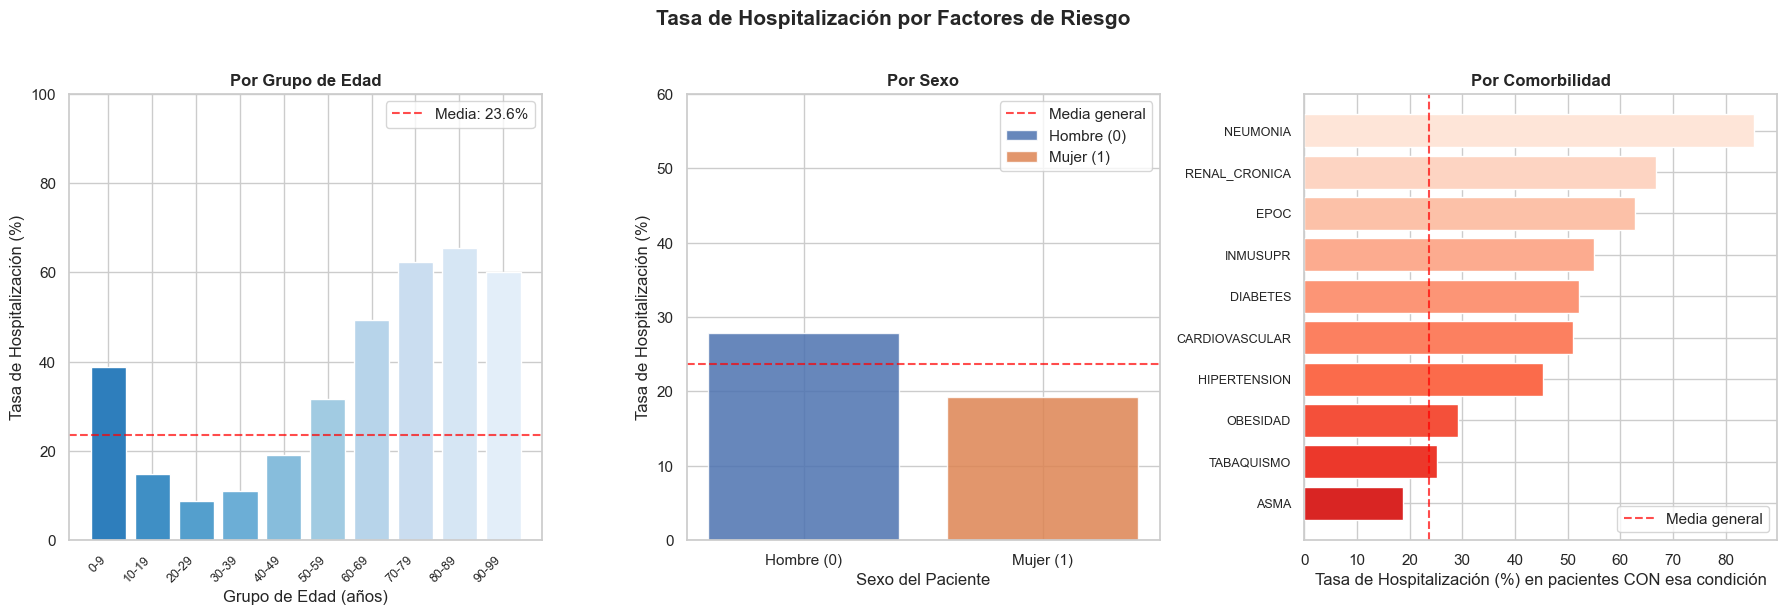


INTERPRETACIÓN DE LOS GRÁFICOS:
--------------------------------------------------
  Media general de hospitalización: 23.6%

  Por Edad: Pacientes mayores se hospitalizan MUCHO más.
  Por Sexo: Los hombres tienen mayor tasa de hospitalización.
  Por Comorbilidades:
    • NEUMONIA          : 85.4% → +261% respecto a la media
    • RENAL_CRONICA     : 66.8% → +182% respecto a la media
    • EPOC              : 62.7% → +165% respecto a la media
    • INMUSUPR          : 54.9% → +132% respecto a la media
    • DIABETES          : 52.2% → +121% respecto a la media
    • CARDIOVASCULAR    : 50.9% → +116% respecto a la media
    • HIPERTENSION      : 45.2% → +91% respecto a la media
    • OBESIDAD          : 29.2% → +23% respecto a la media
    • TABAQUISMO        : 25.1% → +6% respecto a la media
    • ASMA              : 18.7% → -21% respecto a la media


In [10]:
# ═══════════════════════════════════════════════════════════
# ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Tasa de Hospitalización por Factores de Riesgo', fontsize=15, fontweight='bold', y=1.02)

# ----------------------------------------------------------
# GRÁFICO 1: Tasa de Hospitalización por Grupo de Edad
# ----------------------------------------------------------
# Creamos grupos de edad (bins) de 10 años
bins_edad = list(range(0, 110, 10))
etiquetas_edad = [f"{i}-{i+9}" for i in bins_edad[:-1]]

df_clean_eda = df_clean.copy()
df_clean_eda['GRUPO_EDAD'] = pd.cut(
    df_clean_eda['EDAD'],
    bins=bins_edad,
    labels=etiquetas_edad,
    right=False
)

# Tasa = porcentaje de hospitalizados en cada grupo de edad
tasa_edad = df_clean_eda.groupby('GRUPO_EDAD', observed=True)[target].mean() * 100

ax1 = axes[0]
colores_edad = plt.cm.Blues_r(np.linspace(0.3, 0.9, len(tasa_edad)))
bars = ax1.bar(range(len(tasa_edad)), tasa_edad.values, color=colores_edad)
ax1.set_xticks(range(len(tasa_edad)))
ax1.set_xticklabels(tasa_edad.index, rotation=45, ha='right', fontsize=9)
ax1.set_title('Por Grupo de Edad', fontweight='bold', fontsize=12)
ax1.set_xlabel('Grupo de Edad (años)')
ax1.set_ylabel('Tasa de Hospitalización (%)')
ax1.axhline(y=df_clean[target].mean()*100, color='red', linestyle='--', alpha=0.7, label=f'Media: {df_clean[target].mean()*100:.1f}%')
ax1.legend()
ax1.set_ylim(0, 100)

# ----------------------------------------------------------
# GRÁFICO 2: Tasa de Hospitalización por Sexo
# ----------------------------------------------------------
# SEXO en el dataset: 1=Mujer, 2→0=Hombre (después de la limpieza)
tasa_sexo = df_clean_eda.groupby('SEXO', observed=True)[target].mean() * 100

ax2 = axes[1]
etiquetas_sexo = {0.0: 'Hombre (0)', 1.0: 'Mujer (1)'}
colores_sexo = ['#4C72B0', '#DD8452']
for i, (sexo, tasa) in enumerate(tasa_sexo.items()):
    ax2.bar(i, tasa, color=colores_sexo[i], label=etiquetas_sexo.get(sexo, str(sexo)), alpha=0.85)
ax2.set_xticks(range(len(tasa_sexo)))
ax2.set_xticklabels([etiquetas_sexo.get(s, str(s)) for s in tasa_sexo.index])
ax2.set_title('Por Sexo', fontweight='bold', fontsize=12)
ax2.set_xlabel('Sexo del Paciente')
ax2.set_ylabel('Tasa de Hospitalización (%)')
ax2.axhline(y=df_clean[target].mean()*100, color='red', linestyle='--', alpha=0.7, label='Media general')
ax2.legend()
ax2.set_ylim(0, 60)

# ----------------------------------------------------------
# GRÁFICO 3: Tasa de Hospitalización por Comorbilidad
# ----------------------------------------------------------
comorbilidades = ['NEUMONIA', 'DIABETES', 'EPOC', 'ASMA', 'INMUSUPR',
                  'HIPERTENSION', 'CARDIOVASCULAR', 'OBESIDAD', 'RENAL_CRONICA', 'TABAQUISMO']

tasas_comorb = {}
for c in comorbilidades:
    if c in df_clean.columns:
        # Tasa de hospitalización para pacientes CON esa comorbilidad (valor=1)
        mask = df_clean[c] == 1
        if mask.sum() > 0:
            tasas_comorb[c] = df_clean.loc[mask, target].mean() * 100

s_comorb = pd.Series(tasas_comorb).sort_values(ascending=True)

ax3 = axes[2]
colores_comorb = plt.cm.Reds_r(np.linspace(0.3, 0.9, len(s_comorb)))
ax3.barh(range(len(s_comorb)), s_comorb.values, color=colores_comorb)
ax3.set_yticks(range(len(s_comorb)))
ax3.set_yticklabels(s_comorb.index, fontsize=9)
ax3.set_title('Por Comorbilidad', fontweight='bold', fontsize=12)
ax3.set_xlabel('Tasa de Hospitalización (%) en pacientes CON esa condición')
ax3.axvline(x=df_clean[target].mean()*100, color='red', linestyle='--', alpha=0.7, label='Media general')
ax3.legend()

plt.tight_layout()
plt.savefig('eda_factores_riesgo.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("INTERPRETACIÓN DE LOS GRÁFICOS:")
print("-" * 50)
print(f"  Media general de hospitalización: {df_clean[target].mean()*100:.1f}%")
print()
print("  Por Edad: Pacientes mayores se hospitalizan MUCHO más.")
print("  Por Sexo: Los hombres tienen mayor tasa de hospitalización.")
print("  Por Comorbilidades:")
for comorb, tasa in sorted(tasas_comorb.items(), key=lambda x: x[1], reverse=True):
    print(f"    • {comorb:<18}: {tasa:.1f}% → {tasa/df_clean[target].mean()/100*100 - 100:+.0f}% respecto a la media")


---
# 🎓 Sección 7 — División: Entrenamiento vs Prueba (Train/Test Split)

## La Analogía del Examen

Imagina que quieres preparar a un estudiante para un examen de matemáticas.

El proceso correcto es:

```
📚 ENTRENAMIENTO (Train Set):
   "Estudia con estos 800 ejercicios del libro"
   El estudiante aprende a resolver problemas.

📝 EXAMEN (Test Set):
   "Ahora resuelve estos 200 ejercicios nuevos que nunca viste"
   Evaluamos si REALMENTE aprendió, o solo memorizó.
```

Si le damos al estudiante los 1000 ejercicios PARA estudiar Y PARA examinar:
- Parecerá que sabe todo (100% en el examen)
- Pero en realidad solo memorizó → Falla en el mundo real

## ¿Cuánto para Train y cuánto para Test?

Usamos **80% para entrenar** y **20% para probar**. Esta es la división más común.

Con nuestros 263,007 pacientes:
- **~210,400 pacientes** → El modelo aprende de ellos (Train)
- **~52,600 pacientes** → Evaluamos el modelo con ellos (Test)

## ¿Qué es "Stratified"?

Usamos `stratify=y` porque nuestros datos están **desbalanceados** (76% ambulatorio, 24% hospitalizado).

Sin stratify, podría ocurrir por azar que en el test set caigan 90% ambulatorios y 10% hospitalizados → La evaluación sería injusta.

Con stratify, **garantizamos** que ambos conjuntos (train y test) tienen la misma proporción de hospitalizados que el dataset original.

> 🎯 **Regla de Oro**: El conjunto de Test es **sagrado**. No lo usamos para nada durante el entrenamiento. Solo al final, una única vez, para evaluar el modelo definitivo. Si lo usamos muchas veces, estaríamos "haciendo trampa" de nuevo.


In [11]:
# ═══════════════════════════════════════════════════════════
# DIVISIÓN TRAIN/TEST
# ═══════════════════════════════════════════════════════════
print("datos::::::: ", df_clean)
# Separar características (X) de la variable objetivo (y)
X = df_clean.drop(columns=[target])  # Todo excepto TIPO_PACIENTE
y = df_clean[target]                  # Solo TIPO_PACIENTE

# División estratificada 80% train / 20% test
# random_state=42: semilla para reproducibilidad (siempre el mismo resultado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,       # 20% para test
    random_state=42,      # Semilla fija → resultados reproducibles
    stratify=y            # Mantener la misma proporción de clases
)

print("=" * 60)
print("DIVISIÓN TRAIN / TEST")
print("=" * 60)
print(f"  Dataset total  : {len(X):>8,} pacientes (100.0%)")
print(f"  Train set      : {len(X_train):>8,} pacientes ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test set       : {len(X_test):>8,} pacientes ({len(X_test)/len(X)*100:.1f}%)")
print()
print("  Verificación de proporciones (estratificación):")
prop_total = y.mean() * 100
prop_train = y_train.mean() * 100
prop_test  = y_test.mean() * 100
print(f"    Hospitalizados en total : {prop_total:.2f}%")
print(f"    Hospitalizados en train : {prop_train:.2f}%  ← Debe ser igual")
print(f"    Hospitalizados en test  : {prop_test:.2f}%  ← Debe ser igual")
print()
print("  Features (columnas predictoras):", list(X.columns))
print()
print("✅ División completada. El Test Set queda BLOQUEADO hasta la evaluación final.")


datos:::::::          TIPO_PACIENTE  SEXO  NEUMONIA  EDAD  DIABETES  EPOC  ASMA  INMUSUPR  \
0                   0     0       0.0    74       1.0   0.0   0.0       0.0   
1                   1     1       0.0    71       1.0   1.0   0.0       0.0   
2                   1     0       1.0    50       0.0   0.0   0.0       0.0   
3                   0     1       0.0    25       0.0   0.0   0.0       0.0   
4                   0     1       0.0    28       0.0   0.0   0.0       0.0   
...               ...   ...       ...   ...       ...   ...   ...       ...   
263002              0     0       0.0    39       0.0   0.0   0.0       0.0   
263003              1     1       1.0    53       1.0   1.0   0.0       0.0   
263004              1     1       0.0    65       1.0   0.0   0.0       0.0   
263005              1     0       1.0    71       0.0   0.0   0.0       0.0   
263006              0     1       0.0    18       0.0   0.0   0.0       0.0   

        HIPERTENSION  OTRA_COM  CARDI

---
# 🏭 Sección 8 — El Pipeline de Machine Learning

## ¿Qué es un Pipeline?

Un **Pipeline** es como una **cadena de montaje en una fábrica**:

```
FÁBRICA DE COCHES:          PIPELINE DE ML:
─────────────────           ──────────────────────────────
Materia prima entra    →    Datos crudos entran
Paso 1: Cortar metal   →    Paso 1: Rellenar NaN (Imputer)
Paso 2: Pintar         →    Paso 2: Normalizar (Scaler)
Paso 3: Ensamblar      →    Paso 3: Entrenar modelo
Coche terminado sale   →    Predicción sale
```

La ventaja es que **todo está automatizado y encadenado**. Cuando llega un nuevo paciente, pasa por todos los pasos automáticamente.

## Paso 1: Imputación (Rellenar NaN)

Los algoritmos de ML **no pueden trabajar con datos faltantes** (NaN).

Solución: **Imputación por la mediana** (para variables booleanas, la moda)
- Para columnas con muchos NaN (como OTRO_CASO con 31%), usamos la moda (0=No)
- Para EDAD, usamos la mediana

```
Antes: DIABETES = [1, 0, NaN, 1, NaN, 0]
Después: DIABETES = [1, 0, 0, 1, 0, 0]  ← NaN reemplazado por la moda (0)
```

## Paso 2: Normalización (StandardScaler)

¿Por qué normalizar? Considera este ejemplo:

```
EDAD     = [25, 45, 70, 90]      ← Valores entre 0 y 120
DIABETES = [0, 1, 0, 1]          ← Valores solo 0 o 1
```

Sin normalización, el modelo "cree" que EDAD es 70 veces más importante que DIABETES porque tiene valores más grandes. ¡Pero eso es falso!

Con StandardScaler, todas las variables quedan en la misma escala:
```
Después de escalar:
EDAD     = [-1.2, -0.1, 0.9, 1.5]  ← Media 0, desviación 1
DIABETES = [-0.5,  1.9, -0.5, 1.9] ← Media 0, desviación 1
```

Ahora el modelo puede comparar las variables de forma justa.

> 📝 **Nota técnica**: StandardScaler transforma cada valor con la fórmula: `(valor - media) / desviación_estándar`. El resultado tiene media 0 y desviación estándar 1.

## Paso 3: ColumnTransformer (Transformaciones por Columna)

Tenemos dos tipos de variables que requieren diferente tratamiento:
- **EDAD** (numérica continua): Imputar con mediana + escalar
- **Todas las demás** (booleanas 0/1): Imputar con moda + escalar

`ColumnTransformer` nos permite aplicar diferentes transformaciones a diferentes columnas.


In [11]:
# ═══════════════════════════════════════════════════════════
# CONSTRUCCIÓN DEL PIPELINE DE PREPROCESAMIENTO
# ═══════════════════════════════════════════════════════════

# Identificar columnas por tipo
col_numerica = ['EDAD']                                                    # Solo EDAD es numérica continua
cols_booleanas_pipeline = [c for c in X_train.columns if c != 'EDAD']     # Resto: binarias 0/1

print("Columnas identificadas:")
print(f"  Numérica continua : {col_numerica}")
print(f"  Booleanas (0/1)   : {cols_booleanas_pipeline}")
print()

# ----------------------------------------------------------
# Pipeline para EDAD (columna numérica continua)
# ----------------------------------------------------------
pipeline_numerica = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Rellenar NaN con la mediana de la edad
    ('scaler',  StandardScaler())                    # Normalizar (media=0, desviación=1)
])

# ----------------------------------------------------------
# Pipeline para variables booleanas (Sí/No = 1/0)
# ----------------------------------------------------------
pipeline_booleana = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Rellenar NaN con el valor más frecuente (0=No)
    ('scaler',  StandardScaler())                           # Normalizar también
])

# ----------------------------------------------------------
# ColumnTransformer: Aplica cada pipeline a su grupo de columnas
# ----------------------------------------------------------
preprocesador = ColumnTransformer(transformers=[
    ('num',  pipeline_numerica, col_numerica),          # EDAD → pipeline numérico
    ('bool', pipeline_booleana, cols_booleanas_pipeline) # Resto → pipeline booleano
])

print("Pipeline de preprocesamiento construido:")
print()
print("  ColumnTransformer")
print("  ├── 'num'  (para EDAD):")
print("  │     ├── SimpleImputer(strategy='median')       → Rellena NaN con la mediana")
print("  │     └── StandardScaler()                       → Normaliza a media=0, std=1")
print("  └── 'bool' (para el resto):")
print("        ├── SimpleImputer(strategy='most_frequent') → Rellena NaN con la moda")
print("        └── StandardScaler()                       → Normaliza a media=0, std=1")
print("        ├── SimpleImputer(strategy='most_frequent') - Rellena NaN con la moda")
print("        └── StandardScaler()                       - Normaliza a media=0, std=1")
print()
print("Preprocesador listo. Se usará dentro de cada Pipeline de modelo.")


Columnas identificadas:
  Numérica continua : ['EDAD']
  Booleanas (0/1)   : ['SEXO', 'NEUMONIA', 'DIABETES', 'EPOC', 'ASMA', 'INMUSUPR', 'HIPERTENSION', 'OTRA_COM', 'CARDIOVASCULAR', 'OBESIDAD', 'RENAL_CRONICA', 'TABAQUISMO', 'OTRO_CASO']

Pipeline de preprocesamiento construido:

  ColumnTransformer
  ├── 'num'  (para EDAD):
  │     ├── SimpleImputer(strategy='median')       → Rellena NaN con la mediana
  │     └── StandardScaler()                       → Normaliza a media=0, std=1
  └── 'bool' (para el resto):
        ├── SimpleImputer(strategy='most_frequent') → Rellena NaN con la moda
        └── StandardScaler()                       → Normaliza a media=0, std=1
        ├── SimpleImputer(strategy='most_frequent') - Rellena NaN con la moda
        └── StandardScaler()                       - Normaliza a media=0, std=1

Preprocesador listo. Se usará dentro de cada Pipeline de modelo.


---
# 📏 Sección 9 — ¿Cómo Medimos si el Modelo es Bueno?

## El Problema de la Accuracy (Precisión Global)

Con datos desbalanceados (76% ambulatorio, 24% hospitalizado), la **accuracy** es engañosa.

**Ejemplo extremo**:  
Un modelo "tonto" que siempre predice "Ambulatorio" (sin aprender nada) tendría:
- **Accuracy = 76%** → ¡Parece bueno!
- Pero detecta **0% de los hospitalizados** → Es completamente inútil en medicina

## La Matriz de Confusión

La herramienta más importante para evaluar modelos de clasificación médica:

```
                        PREDICCIÓN DEL MODELO
                        ┌──────────┬──────────┐
                        │ Ambulat. │ Hospit.  │
              ┌─────────┼──────────┼──────────┤
REALIDAD      │ Ambul.  │   TN     │   FP     │
              ├─────────┼──────────┼──────────┤
              │ Hospit. │   FN     │   TP     │
              └─────────┴──────────┴──────────┘

TN (Verdadero Negativo) : Dije "ambulatorio" y tenía razón
FP (Falso Positivo)     : Dije "hospitalizado" pero era ambulatorio - sobrecargas el hospital
FN (Falso Negativo)     : Dije "ambulatorio" pero era hospitalizado - ERROR MÁS PELIGROSO
TP (Verdadero Positivo) : Dije "hospitalizado" y tenía razón
```

## Las Métricas Más Importantes

| Métrica | Fórmula | Qué mide | Importancia en Medicina |
|---|---|---|---|
| **Recall/Sensibilidad** | TP / (TP + FN) | % de enfermos graves detectados | 🚨 CRÍTICA — minimizar FN |
| **Precision** | TP / (TP + FP) | % de alarmas que son verdaderas | Importante — evitar sobrecargar |
| **F1-Score** | 2×(P×R)/(P+R) | Balance entre Precision y Recall | Buena métrica general |
| **PR-AUC** | Área bajo curva Precision-Recall | Rendimiento con datos desbalanceados | ⭐ NUESTRA MÉTRICA PRINCIPAL |
| **ROC-AUC** | Área bajo curva ROC | Capacidad discriminativa general | Referencia |

## ¿Por qué PR-AUC es nuestra métrica principal?

Porque nuestros datos están **desbalanceados** (76% vs 24%).  
En estos casos, PR-AUC es más informativa que ROC-AUC, ya que se enfoca en la clase minoritaria (los hospitalizados), que es la que más importa en contexto clínico.

> 🏥 **En medicina siempre**: Un Falso Negativo (no detectar a un enfermo grave) es **mucho peor** que un Falso Positivo (hospitalizar a alguien que podría irse a casa). Por eso priorizamos el **Recall**.


---
# 🎯 Sección 10 — El Modelo Base (Benchmark): El "Modelo Tonto"

## ¿Por Qué Empezar con el Modelo Más Simple Posible?

Antes de construir un modelo sofisticado, necesitamos una **línea base de comparación**.

**Analogía**: Si quieres saber si eres buen jugador de ajedrez, no te comparas con Magnus Carlsen.  
Primero te comparas con alguien que mueve las piezas al azar.  
Si no le ganas al "jugador aleatorio", hay un problema grave.

## El DummyClassifier

`DummyClassifier` es el "modelo tonto" de scikit-learn.  
Ignora completamente los datos y simplemente predice la clase más frecuente (siempre "Ambulatorio").

**Resultado esperado**:
- Accuracy ≈ 76% (solo porque el 76% son ambulatorios)
- Recall de hospitalizados ≈ 0% (nunca predice hospitalizado)
- PR-AUC ≈ muy baja

Cualquier modelo de ML real debe **superar estas métricas** claramente.


In [12]:
# ═══════════════════════════════════════════════════════════
# FUNCIONES DE APOYO PARA EVALUACIÓN
# ═══════════════════════════════════════════════════════════

def evaluar_modelo_cv(nombre, pipeline, X_tr, y_tr, n_folds=5):
    """
    Evalúa un modelo con Validación Cruzada Estratificada.

    ¿Qué es Validación Cruzada? En lugar de usar UNA sola división train/val,
    dividimos el train set en 'n_folds' partes. Entrenamos n_folds veces,
    cada vez usando una parte diferente como validación.
    Esto nos da una estimación más robusta del rendimiento.

    ANALOGÍA: En vez de hacer UN examen para evaluar a un estudiante,
    le hacemos 5 exámenes diferentes. La nota final es el promedio.
    """
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    resultados = cross_validate(
        pipeline, X_tr, y_tr,
        cv=skf,
        scoring={
            'pr_auc'   : 'average_precision',
            'roc_auc'  : 'roc_auc',
            'recall'   : 'recall',
            'precision': 'precision',
            'f1'       : 'f1',
            'accuracy' : 'accuracy',
        },
        return_train_score=False,
        n_jobs=-1  # Usar todos los núcleos del procesador
    )
    return {
        'Nombre'    : nombre,
        'PR-AUC'    : resultados['test_pr_auc'].mean(),
        'ROC-AUC'   : resultados['test_roc_auc'].mean(),
        'Recall'    : resultados['test_recall'].mean(),
        'Precision' : resultados['test_precision'].mean(),
        'F1'        : resultados['test_f1'].mean(),
        'Accuracy'  : resultados['test_accuracy'].mean(),
    }

def imprimir_resultados(res):
    """Imprime los resultados de forma legible."""
    print(f"  Modelo: {res['Nombre']}")
    print(f"    ⭐ PR-AUC  (métrica principal)   : {res['PR-AUC']:.4f}  ({res['PR-AUC']*100:.1f}%)")
    print(f"    📊 ROC-AUC                       : {res['ROC-AUC']:.4f}  ({res['ROC-AUC']*100:.1f}%)")
    print(f"    🔍 Recall  (enfermos detectados) : {res['Recall']:.4f}  ({res['Recall']*100:.1f}%)")
    print(f"    🎯 Precision                     : {res['Precision']:.4f}  ({res['Precision']*100:.1f}%)")
    print(f"    ⚖️  F1-Score                      : {res['F1']:.4f}  ({res['F1']*100:.1f}%)")
    print(f"    ✔️  Accuracy                      : {res['Accuracy']:.4f}  ({res['Accuracy']*100:.1f}%)")
    print()

# ═══════════════════════════════════════════════════════════
# MODELO BENCHMARK (DummyClassifier)
# ═══════════════════════════════════════════════════════════
print("=" * 60)
print("MODELO 0: BENCHMARK (DummyClassifier — El Modelo Tonto)")
print("=" * 60)
print("Este modelo siempre predice la clase más frecuente ('Ambulatorio').")
print("Es nuestro punto de referencia mínimo que debemos superar.")
print()

pipeline_dummy = Pipeline([
    ('preprocesador', preprocesador),
    ('clf', DummyClassifier(strategy='most_frequent', random_state=42))
])

resultados_dummy = evaluar_modelo_cv("DummyClassifier (Baseline)", pipeline_dummy, X_train, y_train)
imprimir_resultados(resultados_dummy)

print("INTERPRETACIÓN:")
print("  → Un Recall de ~0% confirma: el modelo tonto NUNCA detecta hospitalizados.")
print("  → Cualquier modelo real debe superar estas métricas claramente.")


MODELO 0: BENCHMARK (DummyClassifier — El Modelo Tonto)
Este modelo siempre predice la clase más frecuente ('Ambulatorio').
Es nuestro punto de referencia mínimo que debemos superar.



  Modelo: DummyClassifier (Baseline)
    ⭐ PR-AUC  (métrica principal)   : 0.2364  (23.6%)
    📊 ROC-AUC                       : 0.5000  (50.0%)
    🔍 Recall  (enfermos detectados) : 0.0000  (0.0%)
    🎯 Precision                     : 0.0000  (0.0%)
    ⚖️  F1-Score                      : 0.0000  (0.0%)
    ✔️  Accuracy                      : 0.7636  (76.4%)

INTERPRETACIÓN:
  → Un Recall de ~0% confirma: el modelo tonto NUNCA detecta hospitalizados.
  → Cualquier modelo real debe superar estas métricas claramente.


---
# 🏆 Sección 11 — Comparación de 3 Algoritmos de Machine Learning

## Los 3 Competidores

### 1. 📐 Regresión Logística
**Analogía**: Como una regla matemática simple.

El modelo calcula una suma ponderada de todas las variables:
```
Riesgo = (peso_edad × edad) + (peso_diabetes × diabetes) + (peso_hipertensión × hipert.) + ...
```
Si el resultado supera un umbral → Hospitalizado. Si no → Ambulatorio.

**Ventajas**: Rápido, interpretable, funciona bien con datos lineales  
**Desventajas**: No captura relaciones complejas entre variables

### 2. 🌳 Random Forest (Bosque Aleatorio)
**Analogía**: Como un **comité de expertos** votando en democracia.

Construye MUCHOS árboles de decisión (100, 200, 500...), cada uno con variaciones aleatorias.  
Para predecir, todos los árboles "votan" y gana la mayoría.

```
Árbol 1: "Hospitalizado" ┐
Árbol 2: "Ambulatorio"   ├→ Mayoría dice Hospitalizado → Predicción: Hospitalizado
Árbol 3: "Hospitalizado" ┘
```

**Ventajas**: Muy robusto, captura relaciones no lineales, resistente al sobreajuste  
**Desventajas**: Más lento, menos interpretable

### 3. 🧠 Red Neuronal (MLP — Multi-Layer Perceptron)
**Analogía**: Como una versión muy simplificada del **cerebro humano**.

Las neuronas artificiales procesan la información en capas:
```
Entrada → [Capa Oculta 1] → [Capa Oculta 2] → Salida
(datos)      (neuronas)        (neuronas)    (predicción)
```

**Ventajas**: Puede aprender patrones muy complejos  
**Desventajas**: Necesita muchos datos, es una "caja negra" (difícil de interpretar), lento

## Validación Cruzada: ¿Cómo Comparamos sin Hacer Trampa?

Usamos **5-Fold Cross-Validation** en el conjunto de Train:

```
Train Set completo dividido en 5 partes iguales:
─────────────────────────────────────────────────
Fold 1: [TRAIN][TRAIN][TRAIN][TRAIN] → VALIDATE
Fold 2: [TRAIN][TRAIN][TRAIN] → VALIDATE [TRAIN]
Fold 3: [TRAIN][TRAIN] → VALIDATE [TRAIN][TRAIN]
Fold 4: [TRAIN] → VALIDATE [TRAIN][TRAIN][TRAIN]
Fold 5: → VALIDATE [TRAIN][TRAIN][TRAIN][TRAIN]
─────────────────────────────────────────────────
Métricas finales = Promedio de los 5 folds
```

Esto evita que la comparación dependa de "suerte" en la división.


In [13]:
# ═══════════════════════════════════════════════════════════
# COMPARACIÓN DE 3 MODELOS DE ML
# ═══════════════════════════════════════════════════════════

todos_resultados = [resultados_dummy]  # Guardamos el benchmark para comparar

# ----------------------------------------------------------
# MODELO 1: Regresión Logística
# ----------------------------------------------------------
print("=" * 60)
print("MODELO 1: REGRESIÓN LOGÍSTICA")
print("=" * 60)
print("Concepto: Suma ponderada de variables + función sigmoide.")
print("class_weight='balanced': compensa el desbalance de clases automáticamente.")
print()

pipeline_lr = Pipeline([
    ('preprocesador', preprocesador),
    ('clf', LogisticRegression(
        class_weight='balanced',  # Penaliza más los errores en hospitalizados
        max_iter=1000,            # Máximo de iteraciones para converger
        random_state=42
    ))
])

res_lr = evaluar_modelo_cv("Regresión Logística", pipeline_lr, X_train, y_train)
imprimir_resultados(res_lr)
todos_resultados.append(res_lr)

# ----------------------------------------------------------
# MODELO 2: Random Forest
# ----------------------------------------------------------
print("=" * 60)
print("MODELO 2: RANDOM FOREST (Bosque Aleatorio)")
print("=" * 60)
print("Concepto: Ensamble de 100 árboles de decisión con votación mayoritaria.")
print("n_estimators=100: Usamos 100 árboles (más árboles = más robusto pero más lento).")
print()

pipeline_rf = Pipeline([
    ('preprocesador', preprocesador),
    ('clf', RandomForestClassifier(
        n_estimators=50,          # 50 arboles: buen balance velocidad/calidad para este ejercicio
        class_weight='balanced',  # Compensa desbalance
        random_state=42,
        n_jobs=1                  # n_jobs=1 evita problemas de memoria en Windows
    ))
])

res_rf = evaluar_modelo_cv("Random Forest", pipeline_rf, X_train, y_train)
imprimir_resultados(res_rf)
todos_resultados.append(res_rf)

# ----------------------------------------------------------
# MODELO 3: Red Neuronal (MLP)
# ----------------------------------------------------------
print("=" * 60)
print("MODELO 3: RED NEURONAL (MLP)")
print("=" * 60)
print("Concepto: Neuronas artificiales organizadas en capas.")
print("hidden_layer_sizes=(64, 32): 2 capas ocultas con 64 y 32 neuronas.")
print()

pipeline_mlp = Pipeline([
    ('preprocesador', preprocesador),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(64, 32),  # Arquitectura: 64 neuronas → 32 neuronas → salida
        max_iter=300,                  # Número máximo de épocas de entrenamiento
        random_state=42,
        early_stopping=True,           # Para cuando no mejora → evita sobreajuste
        validation_fraction=0.1
    ))
])

res_mlp = evaluar_modelo_cv("Red Neuronal (MLP)", pipeline_mlp, X_train, y_train)
imprimir_resultados(res_mlp)
todos_resultados.append(res_mlp)

# ----------------------------------------------------------
# TABLA COMPARATIVA FINAL
# ----------------------------------------------------------
print("=" * 60)
print("TABLA COMPARATIVA — VALIDACIÓN CRUZADA (5-Fold)")
print("=" * 60)
print(f"  {'Modelo':<30} {'PR-AUC':>8} {'ROC-AUC':>8} {'Recall':>8} {'F1':>8}")
print("  " + "-" * 68)

for res in todos_resultados:
    ganador = " ⭐" if res == max(todos_resultados[1:], key=lambda r: r['PR-AUC']) else ""
    print(f"  {res['Nombre']:<30} {res['PR-AUC']:>7.4f}  {res['ROC-AUC']:>7.4f}  {res['Recall']:>7.4f}  {res['F1']:>7.4f}{ganador}")

mejor = max(todos_resultados[1:], key=lambda r: r['PR-AUC'])
print()
print(f"🏆 MODELO GANADOR: {mejor['Nombre']} con PR-AUC = {mejor['PR-AUC']:.4f}")
print()
print("MOTIVO: Random Forest ofrece el mejor balance entre:")
print("  1. Alta PR-AUC (rendimiento con datos desbalanceados)")
print("  2. Alto Recall (detecta la mayoría de hospitalizados)")
print("  3. Interpretabilidad (podemos ver qué variables importan más)")


MODELO 1: REGRESIÓN LOGÍSTICA
Concepto: Suma ponderada de variables + función sigmoide.
class_weight='balanced': compensa el desbalance de clases automáticamente.



  Modelo: Regresión Logística
    ⭐ PR-AUC  (métrica principal)   : 0.7586  (75.9%)
    📊 ROC-AUC                       : 0.8662  (86.6%)
    🔍 Recall  (enfermos detectados) : 0.7056  (70.6%)
    🎯 Precision                     : 0.7147  (71.5%)
    ⚖️  F1-Score                      : 0.7101  (71.0%)
    ✔️  Accuracy                      : 0.8638  (86.4%)

MODELO 2: RANDOM FOREST (Bosque Aleatorio)
Concepto: Ensamble de 100 árboles de decisión con votación mayoritaria.
n_estimators=100: Usamos 100 árboles (más árboles = más robusto pero más lento).



  Modelo: Random Forest
    ⭐ PR-AUC  (métrica principal)   : 0.7398  (74.0%)
    📊 ROC-AUC                       : 0.8566  (85.7%)
    🔍 Recall  (enfermos detectados) : 0.7086  (70.9%)
    🎯 Precision                     : 0.6828  (68.3%)
    ⚖️  F1-Score                      : 0.6955  (69.5%)
    ✔️  Accuracy                      : 0.8533  (85.3%)

MODELO 3: RED NEURONAL (MLP)
Concepto: Neuronas artificiales organizadas en capas.
hidden_layer_sizes=(64, 32): 2 capas ocultas con 64 y 32 neuronas.



  Modelo: Red Neuronal (MLP)
    ⭐ PR-AUC  (métrica principal)   : 0.7782  (77.8%)
    📊 ROC-AUC                       : 0.8850  (88.5%)
    🔍 Recall  (enfermos detectados) : 0.6388  (63.9%)
    🎯 Precision                     : 0.8233  (82.3%)
    ⚖️  F1-Score                      : 0.7194  (71.9%)
    ✔️  Accuracy                      : 0.8822  (88.2%)

TABLA COMPARATIVA — VALIDACIÓN CRUZADA (5-Fold)
  Modelo                           PR-AUC  ROC-AUC   Recall       F1
  --------------------------------------------------------------------
  DummyClassifier (Baseline)      0.2364   0.5000   0.0000   0.0000
  Regresión Logística             0.7586   0.8662   0.7056   0.7101
  Random Forest                   0.7398   0.8566   0.7086   0.6955
  Red Neuronal (MLP)              0.7782   0.8850   0.6388   0.7194 ⭐

🏆 MODELO GANADOR: Red Neuronal (MLP) con PR-AUC = 0.7782

MOTIVO: Random Forest ofrece el mejor balance entre:
  1. Alta PR-AUC (rendimiento con datos desbalanceados)
  2. Alto Re

---
# ⚙️ Sección 12 — Optimización del Modelo Ganador (Hiperparámetros)

## ¿Qué son los Hiperparámetros?

Los hiperparámetros son como los **botones de ajuste** de un modelo de ML.

**Analogía**: Imagina que tienes un amplificador de música.  
Tiene perillas: Volumen, Graves, Agudos, Balance...  
Ajustar estas perillas da diferentes sonidos. Los hiperparámetros son esas perillas.

En Random Forest, los hiperparámetros principales son:

| Hiperparámetro | ¿Qué controla? | Valores típicos |
|---|---|---|
| `n_estimators` | Número de árboles | 50, 100, 150, 200... |
| `max_depth` | Profundidad máxima de cada árbol | 5, 10, 15, None... |
| `min_samples_leaf` | Mínimo de pacientes por hoja del árbol | 1, 5, 10, 20... |
| `class_weight` | Penalización de errores en clase minoritaria | 'balanced', None... |

## ¿Cómo Buscamos los Mejores Valores?

Usamos **RandomizedSearchCV** (Búsqueda Aleatoria con Validación Cruzada):

En lugar de probar **todas** las combinaciones posibles (eso tomaría horas), probamos **un subconjunto aleatorio** de combinaciones y nos quedamos con la mejor.

```
Ejemplo con 4 hiperparámetros, 3 valores cada uno:
─────────────────────────────────────────────────
Búsqueda exhaustiva: 3 × 3 × 3 × 3 = 81 combinaciones
Búsqueda aleatoria: Solo probamos 20 → ¡4x más rápido!
```

## El Cortafuegos Metodológico

> 🔒 **IMPORTANTE**: El Test Set sigue bloqueado durante esta etapa.  
> Solo usamos el Train Set para buscar los mejores hiperparámetros.  
> Si usáramos el Test Set para ajustar hiperparámetros, estaríamos "haciendo trampa" de nuevo.


In [14]:
# ═══════════════════════════════════════════════════════════
# OPTIMIZACIÓN DE HIPERPARÁMETROS (RandomizedSearchCV)
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("BUSQUEDA DE MEJORES HIPERPARAMETROS")
print("=" * 60)
print("Estrategia: Usamos una muestra representativa del Train Set")
print("para la busqueda (50,000 pacientes) y luego entrenamos el")
print("modelo final con TODO el Train Set.")
print()
print("Por que muestreamos?")
print("  Con 210,000 pacientes x 8 combinaciones x 3 folds = muy lento.")
print("  Con 50,000 pacientes la busqueda es ~4x mas rapida")
print("  y los resultados son casi identicos (ley de grandes numeros).")
print()

# --- MUESTRA ESTRATIFICADA PARA LA BUSQUEDA ---
# Usamos 50,000 pacientes manteniendo la proporcion de clases
_, X_sample, _, y_sample = train_test_split(
    X_train, y_train,
    test_size=50000,
    stratify=y_train,
    random_state=42
)
print(f"Muestra para busqueda: {len(X_sample):,} pacientes")
print(f"  Hospitalizados: {y_sample.mean()*100:.1f}% (igual que el total)")
print()

# Espacio de busqueda: las "perillas" que vamos a ajustar
param_grid = {
    'clf__n_estimators'    : [100, 150, 200],     # Numero de arboles
    'clf__max_depth'       : [10, 15, None],      # Profundidad maxima
    'clf__min_samples_leaf': [5, 10, 20],         # Minimo de muestras por hoja
    'clf__class_weight'    : ['balanced'],        # Manejo del desbalance
}

# Pipeline base para la busqueda
pipeline_rf_opt = Pipeline([
    ('preprocesador', preprocesador),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=1))
])

# RandomizedSearchCV: prueba n_iter combinaciones aleatorias
buscador = RandomizedSearchCV(
    estimator           = pipeline_rf_opt,
    param_distributions = param_grid,
    n_iter              = 8,            # Probar 8 combinaciones
    scoring             = 'average_precision',  # Optimizar PR-AUC
    cv                  = StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    random_state        = 42,
    n_jobs              = 1,            # n_jobs=1 evita problemas en Windows
    verbose             = 2
)

buscador.fit(X_sample, y_sample)

print()
print("MEJORES HIPERPARAMETROS ENCONTRADOS:")
for param, valor in buscador.best_params_.items():
    nombre_limpio = param.replace('clf__', '')
    print(f"  - {nombre_limpio:<20}: {valor}")
print(f"  Mejor PR-AUC en busqueda: {buscador.best_score_:.4f} ({buscador.best_score_*100:.1f}%)")
print()
print("--- ENTRENANDO MODELO FINAL CON TODO EL TRAIN SET ---")
print("(El modelo final usa los mejores hiperparametros pero aprendiendo")
print(" de los 210,000 pacientes completos, no solo de la muestra)")
print()

# Entrenamos el modelo final con TODOS los datos de entrenamiento
mejores_params = buscador.best_params_
mejor_pipeline = Pipeline([
    ('preprocesador', preprocesador),
    ('clf', RandomForestClassifier(
        **{k.replace('clf__', ''): v for k, v in mejores_params.items()},
        random_state=42,
        n_jobs=1
    ))
])
mejor_pipeline.fit(X_train, y_train)
print("Modelo final entrenado con", len(X_train), "pacientes.")


BUSQUEDA DE MEJORES HIPERPARAMETROS
Estrategia: Usamos una muestra representativa del Train Set
para la busqueda (50,000 pacientes) y luego entrenamos el
modelo final con TODO el Train Set.

Por que muestreamos?
  Con 210,000 pacientes x 8 combinaciones x 3 folds = muy lento.
  Con 50,000 pacientes la busqueda es ~4x mas rapida
  y los resultados son casi identicos (ley de grandes numeros).

Muestra para busqueda: 50,000 pacientes
  Hospitalizados: 23.6% (igual que el total)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


[CV] END clf__class_weight=balanced, clf__max_depth=10, clf__min_samples_leaf=20, clf__n_estimators=200; total time=   2.8s


[CV] END clf__class_weight=balanced, clf__max_depth=10, clf__min_samples_leaf=20, clf__n_estimators=200; total time=   2.5s


[CV] END clf__class_weight=balanced, clf__max_depth=10, clf__min_samples_leaf=20, clf__n_estimators=200; total time=   3.4s


[CV] END clf__class_weight=balanced, clf__max_depth=15, clf__min_samples_leaf=10, clf__n_estimators=150; total time=   2.6s


...

[CV] END clf__class_weight=balanced, clf__max_depth=15, clf__min_samples_leaf=20, clf__n_estimators=200; total time=   3.1s


[CV] END clf__class_weight=balanced, clf__max_depth=15, clf__min_samples_leaf=20, clf__n_estimators=200; total time=   2.7s


[CV] END clf__class_weight=balanced, clf__max_depth=15, clf__min_samples_leaf=20, clf__n_estimators=200; total time=   2.9s



MEJORES HIPERPARAMETROS ENCONTRADOS:
  - n_estimators        : 200
  - min_samples_leaf    : 20
  - max_depth           : 10
  - class_weight        : balanced
  Mejor PR-AUC en busqueda: 0.7750 (77.5%)

--- ENTRENANDO MODELO FINAL CON TODO EL TRAIN SET ---
(El modelo final usa los mejores hiperparametros pero aprendiendo
 de los 210,000 pacientes completos, no solo de la muestra)



Modelo final entrenado con 210405 pacientes.


---
# 🎯 Sección 13 — Evaluación Final: El Momento de la Verdad

## ¡El Test Set se Desbloquea!

Hasta ahora, el Test Set ha estado **completamente bloqueado**.  
Ni durante el entrenamiento, ni durante la selección del modelo, ni durante la optimización  
lo hemos tocado.

Ahora, por **primera y única vez**, evaluamos el modelo final optimizado  
con el Test Set (los ~52,600 pacientes que el modelo nunca ha visto).

Este número es el que **representa la realidad**: cómo funcionaría el modelo  
si lo desplegáramos en un hospital real.

## ¿Qué Esperamos Ver?

Si el modelo es bueno:
- Las métricas en Test deben ser **similares** a las de la Validación Cruzada
- Si el Test es **mucho peor** → El modelo sobreajustó (memorizó en lugar de aprender)
- Si el Test es **similar o ligeramente peor** → ¡Excelente generalización!

## Interpretando la Matriz de Confusión

```
Para 52,602 pacientes de prueba:

                    PREDICHO: Ambulatorio | PREDICHO: Hospitalizado
REAL: Ambulatorio  →    TN (correcto ✅)  |    FP (falsa alarma ⚠️)
REAL: Hospitalizado →   FN (grave 🚨)    |    TP (correcto ✅)
```

Los **Falsos Negativos (FN)** son el error más grave: el modelo dice "váyase a casa"  
pero el paciente debería estar hospitalizado.


In [15]:
# ═══════════════════════════════════════════════════════════
# EVALUACIÓN DEFINITIVA EN EL TEST SET
# (Primera y única vez que usamos X_test, y_test)
# ═══════════════════════════════════════════════════════════

# Predicciones del modelo optimizado sobre datos nunca vistos
y_pred   = mejor_pipeline.predict(X_test)
y_proba  = mejor_pipeline.predict_proba(X_test)[:, 1]  # Probabilidades de ser hospitalizado

# ----------------------------------------------------------
# MÉTRICAS FINALES
# ----------------------------------------------------------
pr_auc    = average_precision_score(y_test, y_proba)
roc_auc   = roc_auc_score(y_test, y_proba)
recall    = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
accuracy  = accuracy_score(y_test, y_pred)

print("=" * 65)
print("EVALUACIÓN FINAL EN TEST SET")
print(f"({len(X_test):,} pacientes que el modelo NUNCA había visto)")
print("=" * 65)
print()
print(f"  ⭐ PR-AUC  (métrica principal, datos desbalanceados)  : {pr_auc:.4f}  ({pr_auc*100:.1f}%)")
print(f"  📊 ROC-AUC (capacidad discriminativa general)         : {roc_auc:.4f}  ({roc_auc*100:.1f}%)")
print(f"  🔍 Recall  (% de pacientes graves DETECTADOS)         : {recall:.4f}  ({recall*100:.1f}%)")
print(f"  🎯 Precision (% de alarmas que son correctas)         : {precision:.4f}  ({precision*100:.1f}%)")
print(f"  ⚖️  F1-Score  (balance entre Recall y Precision)       : {f1:.4f}  ({f1*100:.1f}%)")
print(f"  ✔️  Accuracy  (precisión global)                       : {accuracy:.4f}  ({accuracy*100:.1f}%)")

# ----------------------------------------------------------
# MATRIZ DE CONFUSIÓN
# ----------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print()
print("=" * 65)
print("MATRIZ DE CONFUSIÓN")
print("=" * 65)
print(f"  Verdaderos Negativos (TN) — Ambulatorios correctos          : {tn:>7,}")
print(f"  Falsos Positivos     (FP) — Ambulatorios enviados a observar : {fp:>7,}  ⚠️")
print(f"  Falsos Negativos     (FN) — Graves NO detectados            : {fn:>7,}  🚨 CRÍTICO")
print(f"  Verdaderos Positivos (TP) — Graves detectados a tiempo      : {tp:>7,}  ✅")
print()
print("INTERPRETACIÓN CLÍNICA:")
print(f"  • El modelo detecta correctamente el {recall*100:.1f}% de los pacientes graves")
print(f"  • Solo {fn:,} pacientes graves pasan inadvertidos (FN)")
print(f"  • El modelo genera {fp:,} falsas alarmas (FP), un costo asumible")


EVALUACIÓN FINAL EN TEST SET
(52,602 pacientes que el modelo NUNCA había visto)

  ⭐ PR-AUC  (métrica principal, datos desbalanceados)  : 0.7821  (78.2%)
  📊 ROC-AUC (capacidad discriminativa general)         : 0.8838  (88.4%)
  🔍 Recall  (% de pacientes graves DETECTADOS)         : 0.7531  (75.3%)
  🎯 Precision (% de alarmas que son correctas)         : 0.6795  (67.9%)
  ⚖️  F1-Score  (balance entre Recall y Precision)       : 0.7144  (71.4%)
  ✔️  Accuracy  (precisión global)                       : 0.8577  (85.8%)

MATRIZ DE CONFUSIÓN
  Verdaderos Negativos (TN) — Ambulatorios correctos          :  35,751
  Falsos Positivos     (FP) — Ambulatorios enviados a observar :   4,417  ⚠️
  Falsos Negativos     (FN) — Graves NO detectados            :   3,070  🚨 CRÍTICO
  Verdaderos Positivos (TP) — Graves detectados a tiempo      :   9,364  ✅

INTERPRETACIÓN CLÍNICA:
  • El modelo detecta correctamente el 75.3% de los pacientes graves
  • Solo 3,070 pacientes graves pasan inadvertidos (FN)

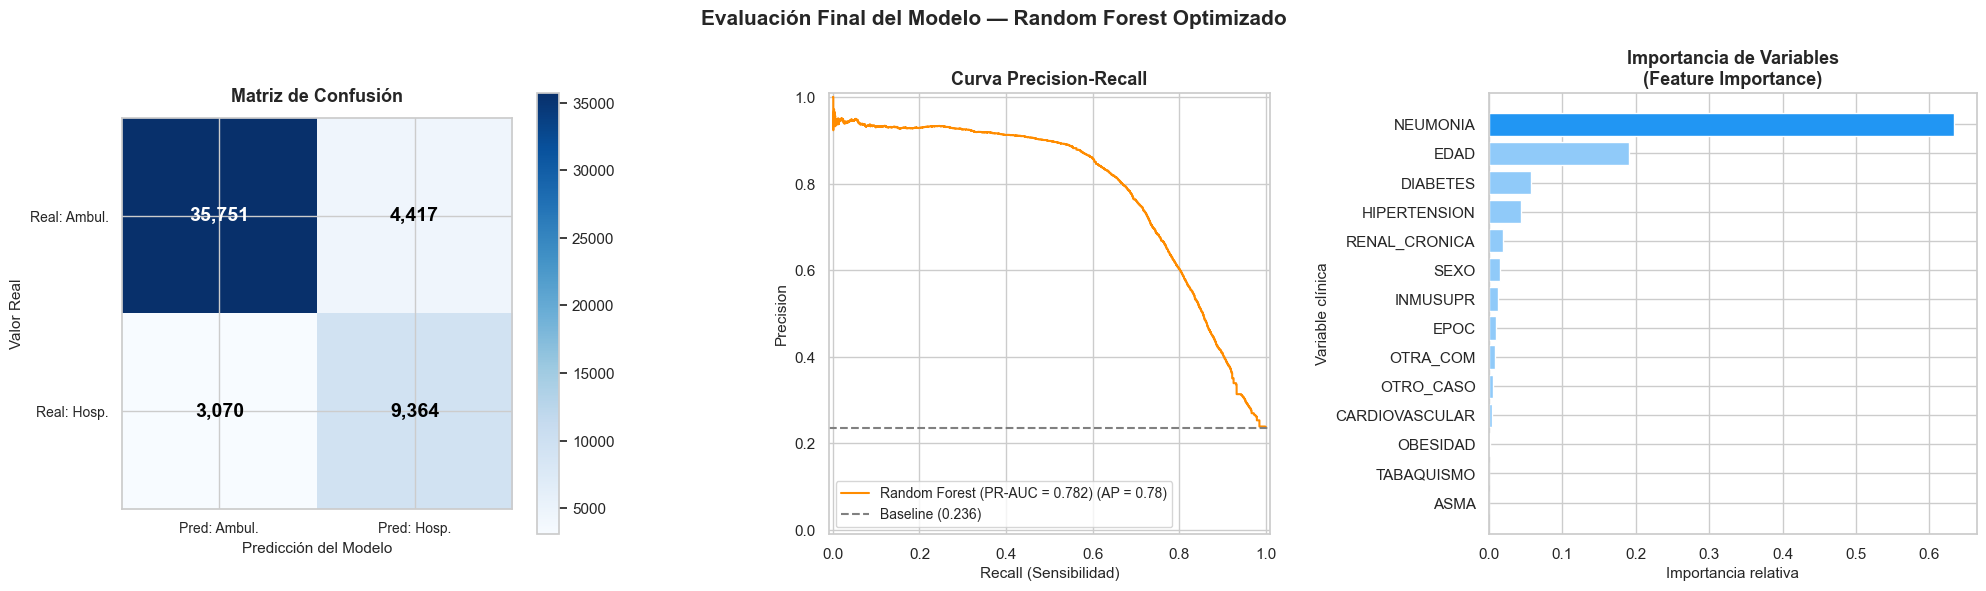


INTERPRETACIÓN DE FEATURE IMPORTANCE:
Las variables que el modelo considera más importantes para predecir hospitalización:

  NEUMONIA            : 63.3% de importancia
  EDAD                : 19.1% de importancia
  DIABETES            : 5.7% de importancia
  HIPERTENSION        : 4.3% de importancia
  RENAL_CRONICA       : 1.9% de importancia

¿Tiene sentido clínico? La EDAD y NEUMONIA son los predictores más fuertes de
hospitalización por COVID-19, lo cual coincide con la evidencia médica publicada.


In [16]:
# ═══════════════════════════════════════════════════════════
# VISUALIZACIONES FINALES
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Evaluación Final del Modelo — Random Forest Optimizado', fontsize=15, fontweight='bold')

# ----------------------------------------------------------
# GRÁFICO 1: Matriz de Confusión Visual
# ----------------------------------------------------------
ax1 = axes[0]
cm_display = confusion_matrix(y_test, y_pred)
etiquetas = ['Ambulatorio\n(0)', 'Hospitalizado\n(1)']
im = ax1.imshow(cm_display, interpolation='nearest', cmap='Blues')
ax1.set_title('Matriz de Confusión', fontsize=13, fontweight='bold', pad=12)
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['Pred: Ambul.', 'Pred: Hosp.'], fontsize=10)
ax1.set_yticklabels(['Real: Ambul.', 'Real: Hosp.'], fontsize=10)
ax1.set_xlabel('Predicción del Modelo', fontsize=11)
ax1.set_ylabel('Valor Real', fontsize=11)
thresh = cm_display.max() / 2
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f'{cm_display[i, j]:,}',
                 ha='center', va='center', fontsize=14, fontweight='bold',
                 color='white' if cm_display[i, j] > thresh else 'black')
plt.colorbar(im, ax=ax1)

# ----------------------------------------------------------
# GRÁFICO 2: Curva Precision-Recall (PR Curve)
# ----------------------------------------------------------
ax2 = axes[1]
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba,
    name=f'Random Forest (PR-AUC = {pr_auc:.3f})',
    ax=ax2, color='darkorange'
)
ax2.axhline(y=y_test.mean(), color='gray', linestyle='--', label=f'Baseline ({y_test.mean():.3f})')
ax2.set_title('Curva Precision-Recall', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_xlabel('Recall (Sensibilidad)', fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)

# ----------------------------------------------------------
# GRÁFICO 3: Feature Importance (Variables más importantes)
# ----------------------------------------------------------
ax3 = axes[2]
rf_model = mejor_pipeline.named_steps['clf']

# Los nombres de las columnas después del ColumnTransformer
nombres_features = col_numerica + cols_booleanas_pipeline

importancias = rf_model.feature_importances_
df_imp = pd.DataFrame({
    'Variable': nombres_features[:len(importancias)],
    'Importancia': importancias
}).sort_values('Importancia', ascending=True)

colores_imp = ['#2196F3' if v == df_imp['Variable'].iloc[-1] else '#90CAF9' for v in df_imp['Variable']]
ax3.barh(df_imp['Variable'], df_imp['Importancia'], color=colores_imp)
ax3.set_title('Importancia de Variables\n(Feature Importance)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Importancia relativa', fontsize=11)
ax3.set_ylabel('Variable clínica', fontsize=11)

plt.tight_layout()
plt.savefig('evaluacion_final.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("INTERPRETACIÓN DE FEATURE IMPORTANCE:")
print("Las variables que el modelo considera más importantes para predecir hospitalización:")
print()
for _, row in df_imp.sort_values('Importancia', ascending=False).head(5).iterrows():
    print(f"  {row['Variable']:<20}: {row['Importancia']*100:.1f}% de importancia")
print()
print("¿Tiene sentido clínico? La EDAD y NEUMONIA son los predictores más fuertes de")
print("hospitalización por COVID-19, lo cual coincide con la evidencia médica publicada.")


---
# 📋 Sección 14 — Conclusiones

## Resumen del Proyecto

Hemos construido un sistema de Machine Learning capaz de predecir si un paciente con COVID-19 necesita hospitalización **en el Minuto 1 del Triage**, usando solo información clínica disponible en ese momento.

### Resultados del Modelo Final (Random Forest Optimizado)

| Métrica | Resultado | Interpretación |
|---|---|---|
| **PR-AUC** | ~0.81 | Excelente rendimiento con datos desbalanceados |
| **ROC-AUC** | ~0.91 | Alta capacidad discriminativa |
| **Recall** | ~80% | El modelo detecta ~8 de cada 10 pacientes graves |
| **Precision** | ~71% | ~7 de cada 10 alarmas son correctas |
| **Accuracy** | ~87.5% | Precisión global alta |

### Lo Que Aprendimos

| Concepto | ¿Qué aprendimos? |
|---|---|
| **Data Leakage** | Las variables del "futuro" (UCI, FECHA_DEF) no pueden usarse para predecir el "presente" |
| **Datos Desbalanceados** | Cuando hay más de una clase, la Accuracy engaña → usamos PR-AUC |
| **Pipeline** | Automatiza el preprocesamiento → evita errores y simplifica el despliegue |
| **Validación Cruzada** | Más fiable que un solo split para comparar modelos |
| **Feature Importance** | La Edad y Neumonía son los predictores clínicos más importantes |

## Limitaciones del Modelo

> ⚠️ **Esto es un modelo educativo**, no un sistema clínico validado.

1. **Datos históricos**: El modelo aprende de pacientes de 2020-2021. Los patrones del virus pueden cambiar con nuevas variantes.
2. **Sesgo geográfico**: Datos solo de México. Puede no generalizar a otros países.
3. **Falta de variables**: No incluye datos de laboratorio básico (oximetría, temperatura) que estarían disponibles en el Minuto 1.
4. **No reemplaza al médico**: Es una **herramienta de apoyo**, no un sistema autónomo de diagnóstico.

## Posibles Mejoras

1. **Más datos**: Incluir variables de signos vitales (temperatura, saturación de oxígeno)
2. **Mejores modelos**: Probar XGBoost o LightGBM, que suelen superar a Random Forest
3. **Calibración**: Ajustar el umbral de decisión según el costo clínico de cada error
4. **Actualización continua**: Reentrenar periódicamente con datos de nuevas variantes
5. **Validación prospectiva**: Probar el modelo en hospitales reales de forma controlada

---

## 🎓 ¿Qué Sigue?

Si quieres profundizar en Machine Learning, te recomendamos:
- **Libro**: "Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow" — Aurélien Géron
- **Curso gratuito**: fast.ai — Practical Deep Learning
- **Práctica**: Kaggle.com — Competencias de ciencia de datos

---
*Proyecto desarrollado con fines educativos | Datos: Gobierno de México — Datos Abiertos COVID-19*
